In [1]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://happy-research.s3.ap-southeast-1.amazonaws.com/toy-datasets/electric_production.csv")

field_name = "IPG2211A2N"

df

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151
...,...,...
392,9/1/2017,98.6154
393,10/1/2017,93.6137
394,11/1/2017,97.3359
395,12/1/2017,114.7212


In [3]:
class CustomTimeSeriesDataset(Dataset):
    def __init__(self, data, window_length, num_outputs, stride): #constructor, window_length being how many items we use for predictio, num_outputs being how many items do we want to predict
        self.data = data
        self.window_length = window_length
        self.num_outputs = num_outputs
        self.stride = stride
        self.num_samples = (data.shape[0] - window_length - num_outputs) // stride + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        start_idx = idx * self.stride
        x = self.data[start_idx : start_idx + self.window_length]
        y = self.data[start_idx + self.window_length : start_idx + self.window_length + self.num_outputs]
        return x, y

In [4]:
window_length = 10
num_outputs = 3
stride = 1

data_tensor = torch.tensor(df[field_name].values, dtype = torch.float32)
data_tensor
time_series_dataset = CustomTimeSeriesDataset(data_tensor, window_length, num_outputs, stride)

sample_1_x, sample_1_y = time_series_dataset[0]
print(sample_1_x)
print(sample_1_y)

tensor([72.5052, 70.6720, 62.4502, 57.4714, 55.3151, 58.0904, 62.6202, 63.2485,
        60.5846, 56.3154])
tensor([58.0005, 68.7145, 73.3057])


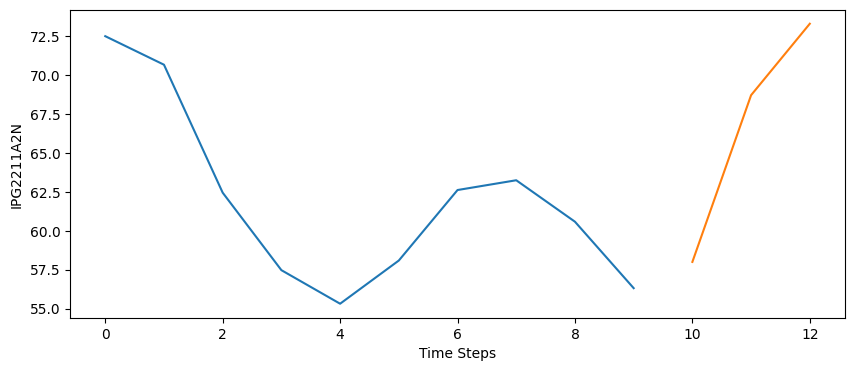

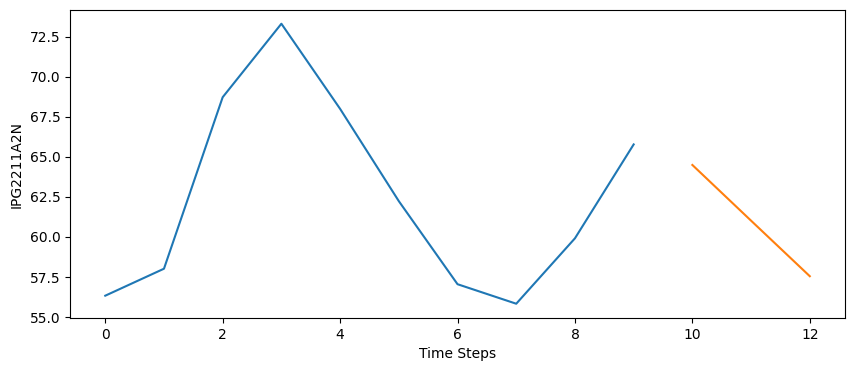

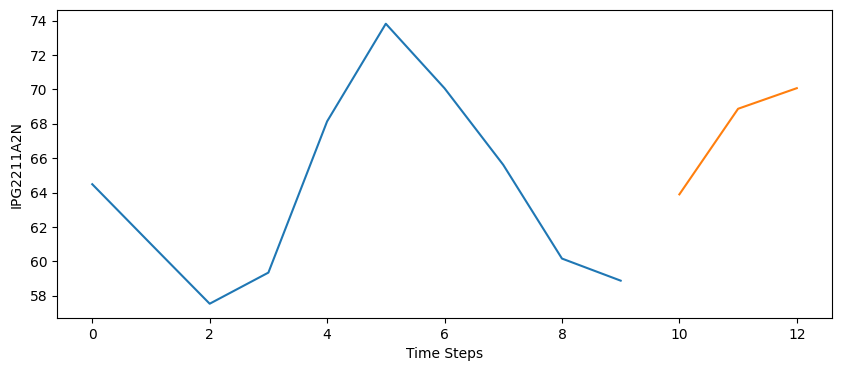

In [5]:
sample_indices = [0, 9, 19]

for idx in sample_indices:
    x, y = time_series_dataset[idx]

    plt.figure(figsize = (10,4))
    plt.plot(range(len(x)), x.cpu().numpy())
    plt.plot(range(len(x), len(x) + len(y)), y.cpu().numpy())
    plt.xlabel("Time Steps")
    plt.ylabel(field_name)
    plt.show()

In [6]:
#Split the dataset
#Split the time_series_dataset into training and validation sets

ratio_training = 0.8
ratio_validation = 1 - ratio_training

size_train = int(ratio_training * len(time_series_dataset))
size_validation = len(time_series_dataset) - size_train

#Split the dataset randomly
train_dataset, val_dataset = torch.utils.data.random_split(time_series_dataset, [size_train, size_validation])

print(f"Training size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")

Training size: 308
Validation size: 77


In [10]:
class SimpleRegressionModel(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.linear1 = nn.Linear(input_size, 64)
        self.linear2 = nn.Linear(64, 32)
        self.linear3 = nn.Linear(32, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.linear1.forward(x)
        x = self.relu.forward(x)

        x = self.linear2.forward(x)
        x = self.relu.forward(x)

        x = self.linear3.forward(x)

        return x

model = SimpleRegressionModel(window_length, num_outputs)
print(model)

SimpleRegressionModel(
  (linear1): Linear(in_features=10, out_features=64, bias=True)
  (linear2): Linear(in_features=64, out_features=32, bias=True)
  (linear3): Linear(in_features=32, out_features=3, bias=True)
  (relu): ReLU()
)


In [11]:
#Define loss function and optimizer
#Choose an appropriate loss function for regression (e.g. Mean Squared Error) and an optimizer (e.g. Adam)

#Loss function
loss_function = nn.MSELoss()

#Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [17]:
#Create dataloader
#Create PyTorch DataLoaders for the training and validation sets to handle batching and shuffling

batch_size = 32

#Dataloader for training
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

#Dataloader for validation
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [20]:
#Create the training function
#Implement the training loop, including forward passes, calculting the loss, backpropagation, and optimzier steps

def train_fn(model, optimizer, loss_fn, train_dataloader, val_dataloader):
    model.train()

    train_loss = 0.0

    for x, y in train_dataloader:
        predictions = model.forward(x)

        loss = loss_function(predictions, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()

    train_loss = train_loss / len(train_dataloader)

    val_loss = 0.0

    #Set the model to eval mode
    model.eval()

    with torch.no_grad():
        for x, y in val_dataloader:
            predictions = model.forward(x)

            loss = loss_function(predictions, y)

            val_loss += loss.item()
        
        val_loss = val_loss / len(val_dataloader)

    return (train_loss, val_loss)


In [22]:
#Train the model
#Go through the training process

num_epochs = 50

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    loss_train, loss_val = train_fn(model, optimizer, loss_function, train_dataloader, val_dataloader)

    train_losses.append(loss_train)
    val_losses.append(loss_val)

    print(f"Epoch [{epoch+1} / {num_epochs}: Train Loss: {loss_train} Val Loss: {loss_val}]")

Epoch [1 / 50: Train Loss: 57.36794204711914 Val Loss: 63.4101193745931]
Epoch [2 / 50: Train Loss: 56.528829956054686 Val Loss: 62.99932988484701]
Epoch [3 / 50: Train Loss: 55.819033813476565 Val Loss: 62.057779947916664]
Epoch [4 / 50: Train Loss: 55.66300010681152 Val Loss: 61.5852902730306]
Epoch [5 / 50: Train Loss: 55.2629695892334 Val Loss: 60.48276138305664]
Epoch [6 / 50: Train Loss: 54.86562843322754 Val Loss: 59.77140808105469]
Epoch [7 / 50: Train Loss: 52.66849708557129 Val Loss: 59.40977350870768]
Epoch [8 / 50: Train Loss: 52.609679794311525 Val Loss: 58.31116739908854]
Epoch [9 / 50: Train Loss: 51.76404228210449 Val Loss: 57.856101989746094]
Epoch [10 / 50: Train Loss: 51.04328384399414 Val Loss: 56.76802444458008]
Epoch [11 / 50: Train Loss: 51.30628700256348 Val Loss: 56.35950597127279]
Epoch [12 / 50: Train Loss: 50.56932182312012 Val Loss: 55.41379928588867]
Epoch [13 / 50: Train Loss: 49.18936042785644 Val Loss: 55.397544860839844]
Epoch [14 / 50: Train Loss: 48.

In [29]:
#Visualize the results of the model
#Given n points into the future, see if the model can create a prediction towards the future

model.eval()

num_future_steps = 200

predicted_sequence = data_tensor.tolist()

add_noise = True

noise_std = 5.0

with torch.no_grad():
    # Iterate through future steps
    for _ in range(num_future_steps):
        input_sequence = torch.tensor(predicted_sequence[-window_length:], dtype=torch.float32) #gets the last entry based on window_length

        predicted_output = model.forward(input_sequence)

        if add_noise:
            noise = torch.randn_like(predicted_output) * noise_std
            predicted_output = predicted_output + noise

        predicted_sequence.extend(predicted_output.tolist())


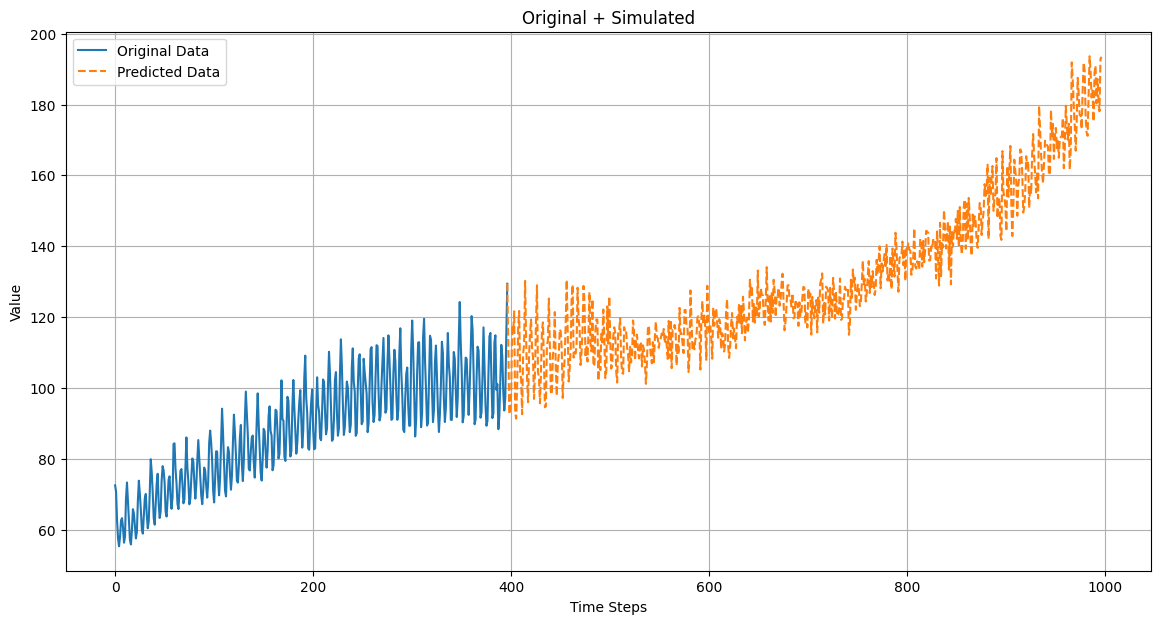

In [30]:
plt.figure(figsize=(14,7))

#Plot the original data
plt.plot(range(len(data_tensor)), data_tensor.numpy(), label="Original Data")

#Plot the predicted future sequences
plt.plot(
    range(len(data_tensor) - 1, len(predicted_sequence)), 
    predicted_sequence[len(data_tensor) -1:],
    label="Predicted Data",
    linestyle = "--"
    )

#Add the title and labels
plt.title("Original + Simulated")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

The plot of the predicted data increases exponentially and does not give us any variation. This is due to the weights being constant in the model.

How do we make the weights non-constant (or how do we apply variation in NN)? A simple solution is to add noise in the confines of what the model thinks is right.